<a href="https://colab.research.google.com/github/pushpendra-saini-pks/CP_LAB/blob/main/CP_LAB4_P.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## CNN using CuDA

In [2]:
import numpy as np
from numba import cuda, float32
import math


 #Convolution Layer

@cuda.jit
def conv2d_kernel(image, kernel, output):
    i, j = cuda.grid(2)

    k_h = kernel.shape[0]
    k_w = kernel.shape[1]

    if i < output.shape[0] and j < output.shape[1]:
        s = 0.0
        for m in range(k_h):
            for n in range(k_w):
                s += image[i + m, j + n] * kernel[m, n]
        output[i, j] = s


# ReLU Activation

@cuda.jit
def relu_kernel(x):
    i = cuda.grid(1)
    if i < x.size:
        if x[i] < 0:
            x[i] = 0



# Max Pooling 2x2

@cuda.jit
def maxpool_kernel(image, output):
    i, j = cuda.grid(2)

    if i < output.shape[0] and j < output.shape[1]:
        r = i * 2
        c = j * 2

        m = image[r, c]
        if image[r, c+1] > m: m = image[r, c+1]
        if image[r+1, c] > m: m = image[r+1, c]
        if image[r+1, c+1] > m: m = image[r+1, c+1]

        output[i, j] = m



# Dense Layer

@cuda.jit
def dense_kernel(x, weights, bias, output):
    i = cuda.grid(1)

    if i < output.size:
        s = 0.0
        for j in range(x.size):
            s += x[j] * weights[j, i]
        output[i] = s + bias[i]



# Sigmoid Activation

@cuda.jit
def sigmoid_kernel(x):
    i = cuda.grid(1)
    if i < x.size:
        x[i] = 1 / (1 + math.exp(-x[i]))


In [3]:
# dummy image 28x28
image = np.random.rand(28, 28).astype(np.float32)
kernel = np.random.rand(3, 3).astype(np.float32)

# allocate GPU memory
d_image = cuda.to_device(image)
d_kernel = cuda.to_device(kernel)
conv_out = cuda.device_array((26, 26), dtype=np.float32)

# launch convolution
threads = (16, 16)
blocks = (2, 2)
conv2d_kernel[blocks, threads](d_image, d_kernel, conv_out)

# ReLU
relu_kernel[256, 256](conv_out.reshape(-1))

# Max pooling
pool_out = cuda.device_array((13, 13), dtype=np.float32)
maxpool_kernel[blocks, threads](conv_out, pool_out)

# Flatten
flat = pool_out.copy_to_host().reshape(-1).astype(np.float32)
d_flat = cuda.to_device(flat)

# Dense layer
weights = np.random.rand(flat.size, 1).astype(np.float32)
bias = np.array([0.1], dtype=np.float32)

d_weights = cuda.to_device(weights)
d_bias = cuda.to_device(bias)
dense_out = cuda.device_array(1, dtype=np.float32)

dense_kernel[1, 1](d_flat, d_weights, d_bias, dense_out)

# Sigmoid
sigmoid_kernel[1, 1](dense_out)

result = dense_out.copy_to_host()
print("Prediction:", result)


/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 4 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 4 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


Prediction: [1.]


/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


In [9]:
import numpy as np

def generate_synthetic_face(size=(28, 28)):
    """
    Generates a 28x28 grayscale numpy array representing a simple face-like pattern
    (e.g., a Gaussian blob). Values are in the range [0, 1].
    """
    x = np.linspace(-1, 1, size[1])
    y = np.linspace(-1, 1, size[0])
    X, Y = np.meshgrid(x, y)

    # Create a central Gaussian blob for the 'face'
    face_pattern = np.exp(-(X**2 + Y**2) / 0.5)

    # Add a slight asymmetry or other features for variation
    # For simplicity, we keep it a smooth blob here. Additional features can be added.

    # Normalize to [0, 1]
    face_pattern = (face_pattern - face_pattern.min()) / (face_pattern.max() - face_pattern.min())

    return face_pattern.astype(np.float32)

print("Defined generate_synthetic_face function.")

Defined generate_synthetic_face function.


In [10]:
def apply_mask(image):
    """
    Applies a black rectangular mask to the lower half of a 28x28 grayscale image.
    The mask is simulated by setting pixel values to 0 in a specific region.
    """
    masked_image = np.copy(image)
    # Define the mask region: lower half of the image
    # For a 28x28 image, start masking from row 14 to the end.
    mask_start_row = image.shape[0] // 2
    masked_image[mask_start_row:, :] = 0.0  # Set pixel values to 0 (black)
    return masked_image.astype(np.float32)

print("Defined apply_mask function.")

Defined apply_mask function.


In [11]:
simulated_images = []
simulated_labels = []

# Generate unmasked face images
for i in range(2):
    face = generate_synthetic_face()
    simulated_images.append(face)
    simulated_labels.append('unmasked')
    print(f"Generated unmasked face image {i+1} with shape {face.shape} and dtype {face.dtype}")

# Generate masked face images
for i in range(2):
    face = generate_synthetic_face()
    masked_face = apply_mask(face)
    simulated_images.append(masked_face)
    simulated_labels.append('masked')
    print(f"Generated masked face image {i+1} with shape {masked_face.shape} and dtype {masked_face.dtype}")

print(f"Total simulated images: {len(simulated_images)}")
print(f"Total simulated labels: {len(simulated_labels)}")

Generated unmasked face image 1 with shape (28, 28) and dtype float32
Generated unmasked face image 2 with shape (28, 28) and dtype float32
Generated masked face image 1 with shape (28, 28) and dtype float32
Generated masked face image 2 with shape (28, 28) and dtype float32
Total simulated images: 4
Total simulated labels: 4


In [12]:
predictions = []

# Define blocks and threads based on previous usage, adjusting for new output sizes where necessary
threads_per_block_2d = (16, 16) # For 2D kernels like conv2d and maxpool
threads_per_block_1d = 256    # For 1D kernels like relu

for i, image in enumerate(simulated_images):
    # 3a. Transfer the image to the GPU
    d_image = cuda.to_device(image)

    # 3b. Define kernel and output dimensions for convolution layer (28x28 input -> 26x26 output with 3x3 kernel)
    conv_out_shape = (image.shape[0] - kernel.shape[0] + 1, image.shape[1] - kernel.shape[1] + 1)
    conv_out = cuda.device_array(conv_out_shape, dtype=np.float32)

    # Determine blocks for conv2d_kernel
    blocks_conv = (math.ceil(conv_out_shape[0] / threads_per_block_2d[0]),
                   math.ceil(conv_out_shape[1] / threads_per_block_2d[1]))

    # 3c. Launch the conv2d_kernel
    conv2d_kernel[blocks_conv, threads_per_block_2d](d_image, d_kernel, conv_out)

    # 3d. Apply ReLU activation
    relu_input_size = conv_out.size
    blocks_relu = (relu_input_size + threads_per_block_1d - 1) // threads_per_block_1d
    relu_kernel[blocks_relu, threads_per_block_1d](conv_out.reshape(-1))

    # 3e. Define output dimensions for max pooling (26x26 input -> 13x13 output with 2x2 pooling)
    pool_out_shape = (conv_out_shape[0] // 2, conv_out_shape[1] // 2)
    pool_out = cuda.device_array(pool_out_shape, dtype=np.float32)

    # Determine blocks for maxpool_kernel
    blocks_maxpool = (math.ceil(pool_out_shape[0] / threads_per_block_2d[0]),
                      math.ceil(pool_out_shape[1] / threads_per_block_2d[1]))

    # 3f. Launch the maxpool_kernel
    maxpool_kernel[blocks_maxpool, threads_per_block_2d](conv_out, pool_out)

    # 3g. Flatten the pooled output
    flat = pool_out.copy_to_host().reshape(-1).astype(np.float32)
    d_flat = cuda.to_device(flat)

    # 3h. Perform the Dense layer calculation. (Output is a single neuron)
    # Ensure weights and bias are compatible. weights should be (flat.size, 1)
    # d_weights and d_bias were already defined in previous cells.
    dense_out = cuda.device_array(1, dtype=np.float32)

    # 3i. Launch the dense_kernel
    dense_kernel[1, 1](d_flat, d_weights, d_bias, dense_out)

    # 3j. Apply Sigmoid activation
    sigmoid_kernel[1, 1](dense_out)

    # 3k. Copy the final prediction back to the host and append to predictions list
    result = dense_out.copy_to_host()
    predictions.append(result[0])
    print(f"Processed image {i+1} ({simulated_labels[i]}): Prediction = {result[0]:.4f}")

print("\nAll images processed. Predictions:", predictions)

Processed image 1 (unmasked): Prediction = 1.0000
Processed image 2 (unmasked): Prediction = 1.0000
Processed image 3 (masked): Prediction = 1.0000
Processed image 4 (masked): Prediction = 1.0000

All images processed. Predictions: [np.float32(1.0), np.float32(1.0), np.float32(1.0), np.float32(1.0)]


/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 3 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


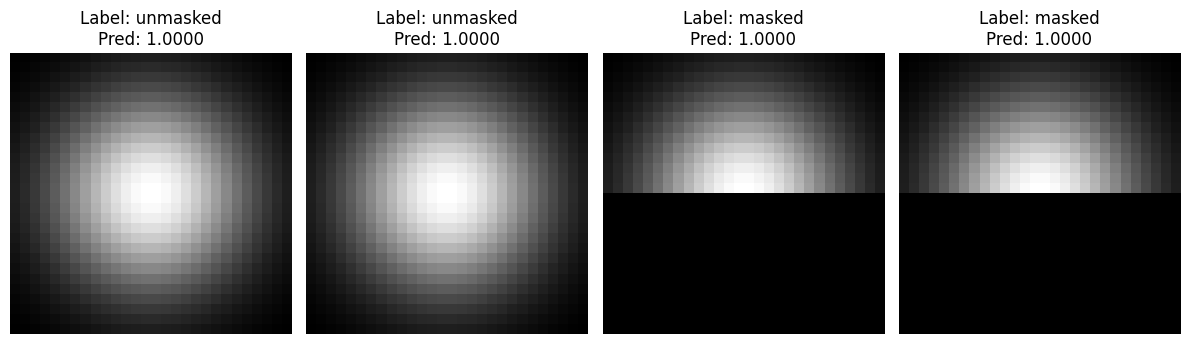

In [14]:
import matplotlib.pyplot as plt

# Visualize a few samples
num_samples_to_visualize = min(len(simulated_images), 4) # Visualize up to 4 images

plt.figure(figsize=(12, 8))
for i in range(num_samples_to_visualize):
    plt.subplot(1, num_samples_to_visualize, i + 1)
    plt.imshow(simulated_images[i], cmap='gray')
    title = f"Label: {simulated_labels[i]}\nPred: {predictions[i]:.4f}"
    plt.title(title)
    plt.axis('off')

plt.tight_layout()
plt.show()
